# VLISM structure functions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats, signal
from scipy.stats import linregress


from fbm import FBM

# Add .. to the path
import sys

sys.path.append("..")
import src.sf_funcs as sf_funcs

plt.rc("font", family="Arial")

## Load data

In [2]:
v1_raw = pd.read_pickle("../data/interim/voyager/voyager1_lism_cleaned.pkl")
v1_raw.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7461001 entries, 2012-08-25 00:00:00 to 2023-12-31 00:00:00
Freq: 48s
Data columns (total 4 columns):
 #   Column  Dtype  
---  ------  -----  
 0   F1      float32
 1   BR      float32
 2   BT      float32
 3   BN      float32
dtypes: float32(4)
memory usage: 170.8 MB


In [3]:
v1_res = v1_raw.resample("1d").mean()
v1_res.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4146 entries, 2012-08-25 to 2023-12-31
Freq: D
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   F1      3969 non-null   float32
 1   BR      3969 non-null   float32
 2   BT      3969 non-null   float32
 3   BN      3969 non-null   float32
dtypes: float32(4)
memory usage: 97.2 KB


In [4]:
v2_raw = pd.read_pickle("../data/interim/voyager/voyager2_lism.pkl")
v2_res = v2_raw.resample("1d").mean()
v2_res.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1518 entries, 2018-11-05 to 2022-12-31
Freq: D
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   F1      1438 non-null   float32
 1   BR      1438 non-null   float32
 2   BT      1438 non-null   float32
 3   BN      1438 non-null   float32
dtypes: float32(4)
memory usage: 35.6 KB


## Low-res SFs (daily)

In [5]:
lags_v1_lr = np.arange(1, len(v1_res))
lags_v2_lr = np.arange(1, len(v2_res))

In [6]:
sf_v1_lr = sf_funcs.compute_sf_fast(v1_res[["BR", "BT", "BN"]], lags_v1_lr, [2])
sf_v2_lr = sf_funcs.compute_sf_fast(v2_res[["BR", "BT", "BN"]], lags_v2_lr, [2])

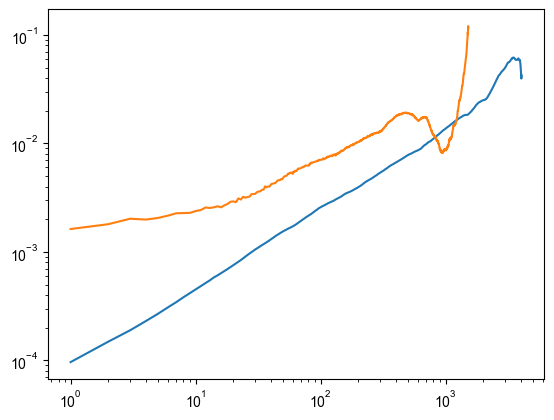

In [7]:
plt.loglog(lags_v1_lr, sf_v1_lr)
plt.loglog(lags_v2_lr, sf_v2_lr)

### Investigating noise

Fraternale reduced noise in his lag-domain stats using 6-point (288s) averaging. I don't know how he quantified that - but here I'm trying a different method, observing the *nugget* (y-intercept of the SF). However, the noise is only a component of this (the other being sub-cadence variability), so it is only an indication. **The actual noise-handling should be subtracting at least the minimum reported instrument noise**. We just need to quantify what this is for our vector SF -> should be 3x (but for our normalized version?).

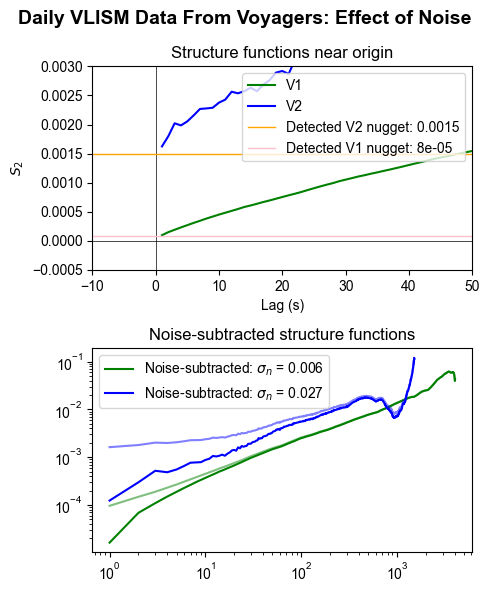

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 6))

ax1.plot(
    lags_v1_lr,
    sf_v1_lr,
    label="V1",
    color="green",
)
ax1.plot(
    lags_v2_lr,
    sf_v2_lr,
    label="V2",
    color="blue",
)

# Set axis limits
ax1.set_xlim(-10, 50)
ax1.set_ylim(-0.0005, 0.003)
# Add horizontal line at y=0
ax1.axhline(0, color="black", linewidth=0.5)
ax1.axvline(0, color="black", linewidth=0.5)

nugget_v2_lr = 0.0015
nugget_v1_lr = 0.00008
sigma_err_v2_lr = np.sqrt(nugget_v2_lr / 2)
sigma_err_v1_lr = np.sqrt(nugget_v1_lr / 2)

ax1.axhline(
    nugget_v2_lr,
    color="orange",
    linestyle="-",
    linewidth=1,
    label=f"Detected V2 nugget: {nugget_v2_lr}",
)
ax1.axhline(
    nugget_v1_lr,
    color="pink",
    linestyle="-",
    linewidth=1,
    label=f"Detected V1 nugget: {nugget_v1_lr}",
)

ax1.legend(loc="upper right")
ax1.set_xlabel("Lag (s)")
ax1.set_ylabel("$S_2$")
ax1.set_title("Structure functions near origin")

ax2.set_title("Noise-subtracted structure functions")
ax2.loglog(lags_v1_lr, sf_v1_lr, color="green", alpha=0.5)
ax2.loglog(
    lags_v1_lr,
    sf_v1_lr - nugget_v1_lr,
    color="green",
    label=f"Noise-subtracted: $\sigma_n$ = {sigma_err_v1_lr:.3f}",
)
ax2.loglog(
    lags_v2_lr,
    sf_v2_lr,
    color="blue",
    alpha=0.5,
)
ax2.loglog(
    lags_v2_lr,
    sf_v2_lr - nugget_v2_lr,
    color="blue",
    label=f"Noise-subtracted: $\sigma_n$ = {sigma_err_v2_lr:.3f}",
)
ax2.legend()

plt.suptitle(
    "Daily VLISM Data From Voyagers: Effect of Noise",
    fontsize=14,
    fontweight="bold",
    x=0.5,
)
plt.tight_layout()

The reported noise level for V2 RTN is 0.06, 0.03, 0.03. I still need to calculate the expected vector SF version. Also, I would have thought this would have disappeared with averaging.

- V2 SF consistent higher power from clearly larger fluctuations (db/B0 = ?). Having subtracted the noise, it is reasonably monofractal K41 up to about 4e7=1.3 years, at which point it dips to a trough at 8e7 = 2.5 years.
- V1 SF very smooth and monofractal, marginally steeper than K41. 

## High-res SFs (48s)

In [10]:
v1_raw_lint = v1_raw.interpolate(method="linear")
v2_raw_lint = v2_raw.interpolate(method="linear")

In [11]:
v1_length = int(7.5e6) # Can go up to 7.5e6 for V1, 2.7e6 for V2
v2_length = int(2.7e6) # V2 length is 2.7e6
nlags = 100

lags_v1_hr = np.logspace(0, np.log10(v1_length), nlags)
# Convert array to integers
lags_v1_hr = [int(x) for x in lags_v1_hr]
# Drop duplicate lags
lags_v1_hr = np.unique([int(x) for x in lags_v1_hr])

lags_v2_hr = np.logspace(0, np.log10(v2_length), nlags)
# Convert array to integers
lags_v2_hr = [int(x) for x in lags_v2_hr]
# Drop duplicate lags
lags_v2_hr = np.unique([int(x) for x in lags_v2_hr])

In [12]:
# FOR THE SAKE OF GOOD GP TIME SERIES, CREATING SMALL SFS WITH LINEAR LAGS

lags_v1_hr_linear = np.arange(1, 20000)

sf_v1_hr_linear, sf_v1_hr_gp_linear = sf_funcs.compute_sf_fast(
    v1_raw[["BR", "BT", "BN"]][:20000],
    lags_v1_hr_linear,
    [2],
    return_missing=True
)



sf_v2_hr_linear, sf_v2_hr_gp_linear = sf_funcs.compute_sf_fast(

    v2_raw[["BR", "BT", "BN"]][:20000],
    lags_v1_hr_linear,
    [2],
    return_missing=True,
)

In [13]:
sf_v1_hr_lint_linear = sf_funcs.compute_sf_fast(
    v1_raw_lint[["BR", "BT", "BN"]][:20000], lags_v1_hr_linear, [2]
)

sf_v2_hr_lint_linear = sf_funcs.compute_sf_fast(
    v2_raw_lint[["BR", "BT", "BN"]][:20000], lags_v1_hr_linear, [2]
)

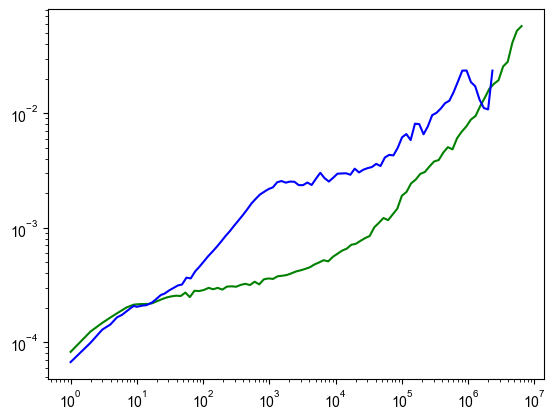

In [14]:
v1_raw_sub = v1_raw[:v1_length]
v2_raw_sub = v2_raw[:v2_length]

sf_v1_hr, sf_v1_hr_gp = sf_funcs.compute_sf_fast(
    v1_raw_sub[["BR", "BT", "BN"]],
    lags_v1_hr,
    [2],
    return_missing=True,
)

sf_v2_hr, sf_v2_hr_gp = sf_funcs.compute_sf_fast(
    v2_raw_sub[["BR", "BT", "BN"]],
    lags_v2_hr,
    [2],
    return_missing=True,
)

plt.loglog(lags_v1_hr, sf_v1_hr, label="V1", c = "green")
plt.loglog(lags_v2_hr, sf_v2_hr, label="V2", c= "blue")

In [15]:
v1_raw_lint_sub = v1_raw_lint[:v1_length]
sf_v1_hr_lint = sf_funcs.compute_sf_fast(
    v1_raw_lint_sub[["BR", "BT", "BN"]],
    lags_v1_hr,
    [2]
)

v2_raw_lint_sub = v2_raw_lint[:v2_length]
sf_v2_hr_lint = sf_funcs.compute_sf_fast(
    v2_raw_lint_sub[["BR", "BT", "BN"]],
    lags_v2_hr,
    [2]
)

### Investigating noise

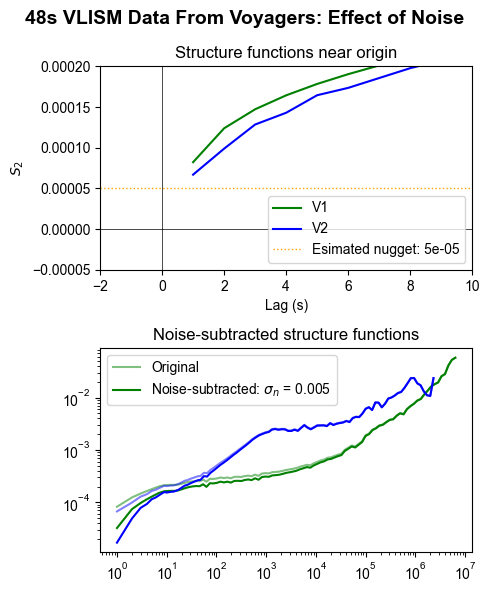

In [16]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 6))

ax1.plot(
    lags_v1_hr,
    sf_v1_hr,
    label="V1",
    color="green",
)
ax1.plot(
    lags_v2_hr,
    sf_v2_hr,
    label="V2",
    color="blue",
)

# Set axis limits
ax1.set_xlim(-2, 10)
ax1.set_ylim(-0.00005, 0.0002)
# Add horizontal line at y=8

ax1.axhline(0, color="black", linewidth=0.5)
ax1.axvline(0, color="black", linewidth=0.5)

#nugget_hr = 0.00006
nugget_hr = 0.00005

sigma_err_hr = np.sqrt(nugget_hr / 2)
# sigma_err_hr = 0.035
# nugget_hr = sigma_err_hr ** 2 * 2

ax1.axhline(
    nugget_hr,
    color="orange",
    linestyle=":",
    linewidth=1,
    label=f"Esimated nugget: {nugget_hr}",
)


ax1.legend()
ax1.set_xlabel("Lag (s)")
ax1.set_ylabel("$S_2$")
ax1.set_title("Structure functions near origin")

ax2.set_title("Noise-subtracted structure functions")
ax2.loglog(
    lags_v1_hr,
    sf_v1_hr,
    alpha=0.5,
    color="green",
    label="Original"
)
ax2.loglog(
    lags_v1_hr,
    sf_v1_hr - nugget_hr,
    color="green",
    label=f"Noise-subtracted: $\sigma_n$ = {sigma_err_hr:.3f}",
)
ax2.loglog(
    lags_v2_hr,
    sf_v2_hr,
    color="blue",
    alpha=0.5,
)
ax2.loglog(
    lags_v2_hr,
    sf_v2_hr - nugget_hr,
    color="blue",
)
ax2.legend()

plt.suptitle(
    "48s VLISM Data From Voyagers: Effect of Noise",
    fontsize=14,
    fontweight="bold",
    x=0.5,
)
plt.tight_layout()

The *component*-wise error is reported to be 0.005nT. For the vector magnitude, we expect 0.009 (but we aren't computing the SF from the magnitude right?). As shown below, this would give us a nugget of about 0.00016.

### Investigating gaps and interpolation

In [17]:
data_plot = v1_raw["F1"]["2016-01-28 10:30":"2016-01-31 10:30"]
data = data_plot.dropna()

# Find gaps (normal interval is 48 seconds, so gaps are longer)
time_diffs = data.index.to_series().diff()
gap_threshold = pd.Timedelta(
    seconds=48 * 1
)  # Consider gaps 3x normal interval or longer 

# Find all gaps above threshold
gaps = time_diffs[time_diffs > gap_threshold]

# For each gap, store start time, end time, and duration
gap_info = []
for gap_end_idx in gaps.index:
    gap_start = data.index[data.index.get_loc(gap_end_idx) - 1]  # Previous data point
    gap_end = gap_end_idx
    gap_duration = gaps[gap_end_idx]
    gap_info.append((gap_start, gap_end, gap_duration))

# Sort by duration and get the 2 largest
gap_info.sort(key=lambda x: x[2], reverse=True)
largest_gaps = gap_info[:4]
smallest_gaps = gap_info[-4:]

# Create list of time ranges covered by the largest gaps
annotated_ranges = []
for gap_start, gap_end, gap_duration in largest_gaps:
    annotated_ranges.append((gap_start, gap_end))

# Find NA values in the data
na_times = data_plot[data_plot.isna()].index

# Filter out NA values that fall within annotated gaps
na_outside_gaps = []
for na_time in na_times:
    is_in_gap = False
    for gap_start, gap_end in annotated_ranges:
        if gap_start <= na_time <= gap_end:
            is_in_gap = True
            break
    if not is_in_gap:
        if na_time > data.index[0] and na_time < data.index[-1]:
            # Only add NA times that are within the data range
            na_outside_gaps.append(na_time)

### Interactive investigation

In [18]:
# import plotly.graph_objects as go

# fig = go.Figure()

# # Plot the data
# fig.add_trace(go.Scatter(
#     x=data_plot.index, y=data_plot.values,
#     mode='lines',
#     line=dict(color='black', width=1),
#     name='MAG data'
# ))

# # Add red vertical lines for NA values outside of annotated gaps
# for na_time in na_outside_gaps:
#     fig.add_vline(
#         x=na_time,
#         line_color='red',
#         line_width=1,
#         opacity=0.6
#     )

# fig.update_layout(
#     title="3 days of MAG data from Voyager 1",
#     xaxis_title="Time",
#     yaxis_title="|B| (nT)",
#     showlegend=False,
#     height=400,
#     width=700
# )
# fig.show()

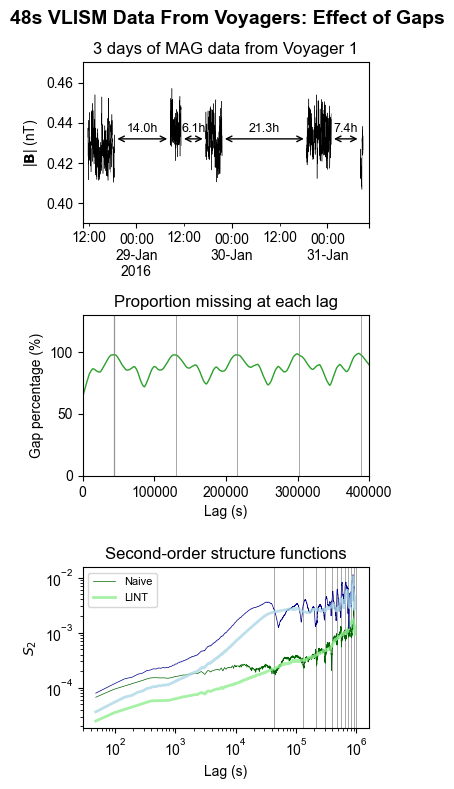

In [19]:
fig, (ax3, ax2, ax1) = plt.subplots(3, 1, figsize=(4, 8))

data_plot.plot(ax=ax3, title="3 days of MAG data from Voyager 1", lw=0.3, color="black")

# Annotate the gaps
for gap_start, gap_end, gap_duration in largest_gaps:
    # Calculate middle of the gap
    gap_middle = gap_start + (gap_end - gap_start) / 2
    gap_duration_hours = gap_duration.total_seconds() / 3600

    # Find appropriate y-position for the annotation
    y_min, y_max = ax3.get_ylim()
    y_pos = (y_min + y_max) / 2

    # Add horizontal line with arrows at both ends spanning the gap
    ax3.annotate(
        "",
        xy=(gap_end, y_pos),
        xytext=(gap_start, y_pos),
        arrowprops=dict(arrowstyle="<->", color="black", lw=1),
    )

    # Add text annotation above the line
    ax3.annotate(
        f"{gap_duration_hours:.1f}h",
        xy=(gap_middle, y_pos),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        # bbox=dict(boxstyle="round,pad=0.3", facecolor="gray", alpha=0.4),
        fontsize=9,
    )
ax3.set_ylabel("|$\\bf{B}$| (nT)")

# Add red vertical lines for NA values outside of annotated gaps
# for na_time in na_outside_gaps:
#     ax3.axvline(x=na_time, color="red", linestyle="-", alpha=0.6, linewidth=1)

# Sample size plot (top, now ax2)
ax2.plot(lags_v1_hr_linear * 48, sf_v1_hr_gp_linear, color="tab:green", lw=1, label="V1")
#ax2.plot(lags_v1_hr_linear * 48, sf_v2_hr_gp_linear, color="tab:blue", lw=1, label="V2")
ax2.set_ylabel("Gap percentage (%)")

# Add vertical lines at multiples of 12 hours to both axes
for i in np.arange(0, 12, 1):
    for ax_ in (ax2, ax1):
        ax_.axvline((12+i * 24) * 3600, color="gray", lw=0.7, alpha=0.7)

# Add one vertical line to the legend
ax2.axvline(
    12 * 3600, color="gray", lw=1, alpha=0.5, label="Multiples of 24 hours"
)
# Add legend to the sample size plot
# ax2.legend(framealpha=0.8, loc="lower center", ncols=2,
#            fontsize=8
#               )

ax1.plot(
    lags_v1_hr_linear * 48,
    sf_v1_hr_linear,
    color="darkgreen",
    label="Naive",
    lw=0.5,
)
ax1.plot(
    lags_v1_hr_linear * 48,
    sf_v1_hr_lint_linear,
    color="lightgreen",
    label="LINT",
    lw=2,
    alpha=0.8,
)
ax1.plot(
    lags_v1_hr_linear * 48,
    sf_v2_hr_linear,
    color="darkblue",
    lw=0.5,
)
ax1.plot(
    lags_v1_hr_linear * 48,
    sf_v2_hr_lint_linear,
    color="lightblue",
    lw=2,
    alpha=0.8,
)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_ylabel("$S_2$")
ax1.set_xlabel("Lag (s)")
ax2.set_xlabel("Lag (s)")
ax3.set_ylim(0.39,0.47)
ax2.set_xlim(0, 4e5)
ax2.set_ylim(0,130)

ax1.set_title("Second-order structure functions")
ax2.set_title("Proportion missing at each lag")
plt.suptitle(
    "48s VLISM Data From Voyagers: Effect of Gaps",
    fontsize=14,
    fontweight="bold",
    x=0.55,
    )
ax1.legend(fontsize=8)
plt.tight_layout()
#plt.savefig("vlism_hr_sfs_gaps.png", dpi=300, bbox_inches="tight")

Making new versions for paper demo figure

Text(0.5, 0, 'Lag (s)')

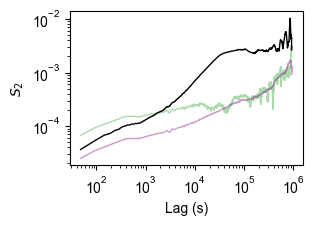

In [20]:
fig, ax1 = plt.subplots(1, 1, figsize=(3, 2))
ax1.plot(
    lags_v1_hr_linear * 48,
    sf_v1_hr_linear,
    color="tab:green",
    lw=1,
    alpha=0.4
)
ax1.plot(
    lags_v1_hr_linear * 48,
    sf_v1_hr_lint_linear,
    color="purple",
    lw=1,
    alpha=0.4,
)
ax1.plot(
    lags_v1_hr_linear * 48,
    sf_v2_hr_lint_linear,
    color="black",
    lw=1,
)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_ylabel("$S_2$")
ax1.set_xlabel("Lag (s)")
# for i in np.arange(0, 10, 1):
#     ax1.axvline((12 + i * 24) * 3600, color="gray", lw=0.7, alpha=0.5)

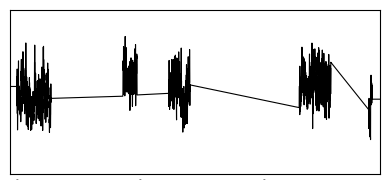

In [21]:
fig, ax3 = plt.subplots(1, 1, figsize=(4, 2))

data_plot_lint = data_plot.interpolate(method="linear").ffill().bfill()

data_plot_lint.plot(
    ax=ax3,lw=0.8, color="black"
)
ax3.set_ylim(0.39, 0.47)
# Remove all labels and ticks
ax3.set_xticks([])  
ax3.set_yticks([])
# Remove tickmarks
ax3.tick_params(
    axis="both", which="both", length=0, labelsize=0
)


# ax3.set_ylabel("|$\\bf{B}$| (nT)")

plt.tight_layout()
# plt.savefig("vlism_hr_sfs_gaps.png", dpi=300, bbox_inches="tight")

- Clear periodicity of gaps is evident in plot of GP as function of lag. 
- V1 shows secondary humps,due to prevalence of 20 hour gaps as well; see image below. 

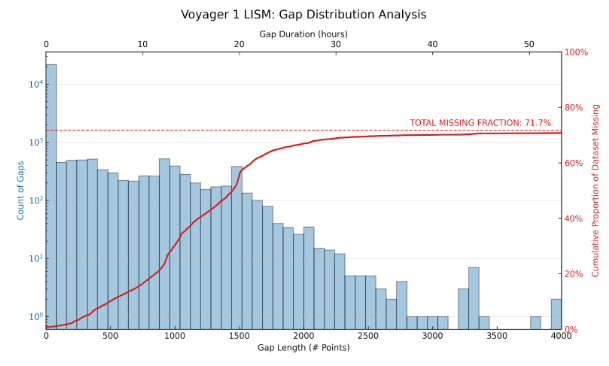


## Combined plot

In [22]:
es_v1_hr = sf_v1_hr * lags_v1_hr * 48 / 6
es_v1_f = 1 / (lags_v1_hr * 48 * 2)
es_v2_hr = sf_v2_hr * lags_v2_hr * 48 / 6
es_v2_f = 1 / (lags_v2_hr * 48 * 2)

In [23]:
import pickle

# Replace with your pickle file path
pickle_file = "../results/full/voyager1_corrected_sfs.pkl"

# Load the list of time series
with open(pickle_file, "rb") as f:
    v1_sfs_gapped_corrected_all = pickle.load(f)


v1_sfs_corrected = v1_sfs_gapped_corrected_all[
    v1_sfs_gapped_corrected_all.gap_handling == "corrected_3d"
]
v1_sfs_corrected["distance"] = v1_sfs_corrected["int_index"] * 1.67 + 120
v1_sfs_corrected["lag_s"] = v1_sfs_corrected["lag"] * 288  # Convert to seconds
v1_sfs_corrected["inverse_lag_s"] = 1 / v1_sfs_corrected["lag_s"]

# Now do the same for V2
pickle_file_v2 = "../results/full/voyager2_corrected_sfs.pkl"
# Load the list of time series
with open(pickle_file_v2, "rb") as f:
    v2_sfs_gapped_corrected_all = pickle.load(f)
v2_sfs_corrected = v2_sfs_gapped_corrected_all[
    v2_sfs_gapped_corrected_all.gap_handling == "corrected_3d"
]
v2_sfs_corrected["distance"] = v2_sfs_corrected["int_index"] * 1.67 + 120
v2_sfs_corrected["lag_s"] = v2_sfs_corrected["lag"] * 288  # Convert to seconds
v2_sfs_corrected["inverse_lag_s"] = 1 / v2_sfs_corrected["lag_s"]

C:\Users\spann\AppData\Local\Temp\ipykernel_15760\2912261232.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  v1_sfs_corrected["distance"] = v1_sfs_corrected["int_index"] * 1.67 + 120
C:\Users\spann\AppData\Local\Temp\ipykernel_15760\2912261232.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  v1_sfs_corrected["lag_s"] = v1_sfs_corrected["lag"] * 288  # Convert to seconds
C:\Users\spann\AppData\Local\Temp\ipykernel_15760\2912261232.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy

In [24]:
(25*48)

1200

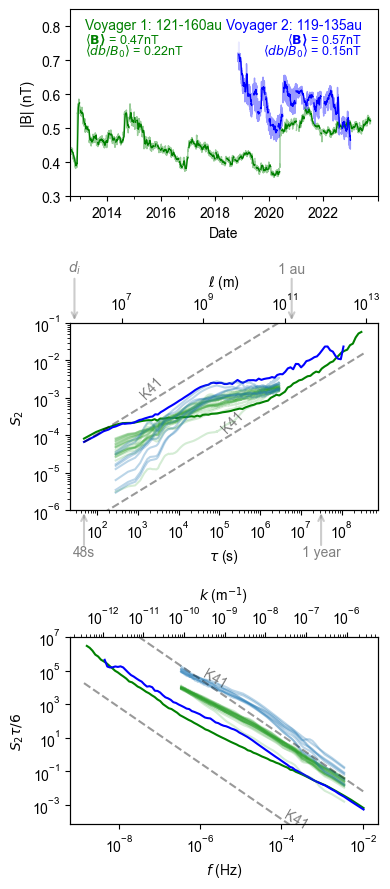

In [106]:
import matplotlib.pyplot as plt
import numpy as np

# Create figure with three subplots
fig, ax = plt.subplots(3, 1, figsize=(4, 9))

# Constants
U = 25000  # m/s (solar wind speed)
AU = 1.496e11  # meters
# PC_001 = 3.086e14  # 0.01 parsec in meters
di = 700000 #  # Ion inertial length in km
# ax[2].annotate("$f_{d_i}$", xy=(0.3 * 6e-3, 6e-8), fontsize=10, c="purple")


# =============================================================================
# Panel 1: Time Series
# =============================================================================
# Plot daily averages with transparency
v1_res["F1"].plot(ax=ax[0], label="Voyager 1 daily avg", c="green", lw=1, alpha=0.4)
v2_res["F1"].plot(ax=ax[0], label="Voyager 2 daily avg", c="blue", lw=1, alpha=0.4)

# Add 2-week moving averages
v1_res["F1"].rolling(window=14).mean().plot(
    ax=ax[0], label="V1 2-week moving avg", c="green", lw=1
)
v2_res["F1"].rolling(window=14).mean().plot(
    ax=ax[0], label="V2 2-week moving avg", c="blue", lw=1
)

ax[0].set_ylabel("|B| (nT)")
ax[0].set_xlabel("Date")

# =============================================================================
# Panel 2: Structure Functions
# =============================================================================
# Plot structure functions
ax[1].plot(lags_v1_hr * 48, sf_v1_hr, color="green", label="V1")
ax[1].plot(lags_v2_hr * 48, sf_v2_hr, color="blue", label="V2")

# Power law reference lines (2/3 scaling)
pwrl_range = np.logspace(np.log10(48), np.log10(11 * 365 * 86400), 100)
ax[1].plot(
    pwrl_range,
    0.000000031 * np.power(pwrl_range, 2 / 3),
    label="$\\tau^{2/3}$",
    color="black",
    linestyle="--",
    alpha=0.4,
)
ax[1].plot(
    pwrl_range,
    0.000005 * np.power(pwrl_range, 2 / 3),
    color="black",
    linestyle="--",
    alpha=0.4,
)


# Corrected SFs
for idx in v1_sfs_corrected["int_index"].unique():
    subset = v1_sfs_corrected[v1_sfs_corrected["int_index"] == idx]
    ax[1].loglog(
        subset["lag_s"],
        subset["sf_2"] / 3000,
        alpha=0.2,
        # label=f"int_index={idx}",
        color="tab:green",
        # title=f"Voyager 1 Corrected SFS (int_index={idx})",
    )
for idx in v2_sfs_corrected["int_index"].unique():
    subset = v2_sfs_corrected[v2_sfs_corrected["int_index"] == idx]
    ax[1].loglog(
        subset["lag_s"],
        subset["sf_2"]/3000,
        alpha=0.3,
        # label=f"int_index={idx}",
        color="tab:blue",
        # title=f"Voyager 1 Corrected SFS (int_index={idx})",
    )

# Time scale reference lines
time_scales = [
    (48, "48s", 0.25),
    (86400, "1 day", 1.1),
    (365 * 86400, "1 year", 1.1),
]

length_scales = [(AU, "1 au", 0.12), (di, "$d_i$", 0.07)]
time_scales = [(48, "48s", 0.25),(365 * 86400, "1 year", 1.1)]
#  (86400, "1 day", 1.1),

ax[1].set_xscale("log")
ax[1].set_yscale("log")
# ax[1].set_xlim(1e1, 2e10)
ax[1].set_xlabel("$\\tau$ (s)")
ax[1].set_ylabel("$S_2$")

# Secondary x-axis for spatial scales
ax1_s = ax[1].twiny()
lag_min, lag_max = ax[1].get_xlim()
d_min, d_max = lag_min * U, lag_max * U
ax1_s.set_xlim(d_min, d_max)
ax1_s.set_xscale("log")
ax1_s.set_xlabel("$\\ell$ (m)")

# =============================================================================
# Panel 3: Equivalent Spectra
# =============================================================================
# Plot equivalent spectra
ax[2].loglog(es_v1_f, es_v1_hr, label="V1", color="green")
ax[2].loglog(es_v2_f, es_v2_hr, label="V2", color="blue")

# Corrected ES
for idx in v1_sfs_corrected["int_index"].unique():
    subset = v1_sfs_corrected[v1_sfs_corrected["int_index"] == idx]
    ax[2].loglog(
        subset["inverse_lag_s"],
        subset["sf_corrected_es"],
        alpha=0.2,
        # label=f"int_index={idx}",
        color="tab:green",
        # title=f"Voyager 1 Corrected SFS (int_index={idx})",
    )
for idx in v2_sfs_corrected["int_index"].unique():
    subset = v2_sfs_corrected[v2_sfs_corrected["int_index"] == idx]
    ax[2].loglog(
        subset["inverse_lag_s"],
        subset["sf_corrected_es"]*10,
        alpha=0.3,
        # label=f"int_index={idx}",
        color="tab:blue",
        # title=f"Voyager 1 Corrected SFS (int_index={idx})",
    )

# Power law reference lines
pwrl_range = np.linspace(es_v1_f[-1], es_v1_f[0], 100)
ax[2].plot(
    pwrl_range,
    0.0000031 * np.power(pwrl_range, -5 / 3),
    label="$f^{-5/3}$",
    color="black",
    linestyle="--",
    alpha=0.4,
)
ax[2].plot(
    pwrl_range,
    0.000000000031 * np.power(pwrl_range, -5 / 3),
    color="black",
    linestyle="--",
    alpha=0.4,
)

ax[2].set_xlabel("$f$ (Hz)")
ax[2].set_ylabel("$S_2\\tau/6$")

# Secondary x-axis for wavenumber
ax2_s = ax[2].twiny()
freq_min, freq_max = ax[2].get_xlim()
k_min, k_max = 2 * np.pi * freq_min / U, 2 * np.pi * freq_max / U
ax2_s.set_xlim(k_min, k_max)
ax2_s.set_xscale("log")
ax2_s.set_xlabel("$k$ (m$^{-1}$)")


for length, label, x_offset in length_scales:
    ax1_s.annotate(
        "",
        xy=(length, 1),  # arrow tip at freq_val, above axis
        xytext=(length, 1.8),  # start of arrow higher up
        textcoords="data",
        arrowprops=dict(arrowstyle="->", color="black", lw=1.5, alpha=0.2),
        annotation_clip=False,
        xycoords=("data", "axes fraction"),
    )
    ax1_s.text(
        length,
        1.25,
        label,
        color="black",
        fontsize=10,
        alpha=0.5,
        ha="center",
        va="bottom",
        transform=ax1_s.get_xaxis_transform(),
        clip_on=False,
    )

for length, label, x_offset in time_scales:
    ax[1].annotate(
        "",
        xy=(length, 1e-6),  # arrow tip at freq_val, above axis
        xytext=(length, 1e-7),  # start of arrow higher up
        textcoords="data",
        arrowprops=dict(arrowstyle="->", color="black", lw=1.5, alpha=0.2),
        annotation_clip=False,
        #xycoords=("data", "axes fraction"),
    )
    ax[1].text(
        length,
        5e-8,
        label,
        color="black",
        fontsize=10,
        alpha=0.5,
        ha="center",
        va="bottom",
        #transform=ax[1].get_xaxis_transform(),
        clip_on=False,
    )

# Add green text annotation above ax[0] for Voyager 1


ax[1].text(
    1e3,
    1e-3,
    "K41",
    rotation=45,
    alpha=0.5,
    fontsize=10,
)
ax[1].text(
    1e5,
    1.2e-4,
    "K41",
    rotation=45,
    alpha=0.5,
    fontsize=10,
)
ax[2].text(
    1e-4,
    4e-5,
    "K41",
    rotation=-30,
    alpha=0.5,
    fontsize=10,
)
ax[2].text(
    1e-6,
    1e4,
    "K41",
    rotation=-30,
    alpha=0.5,
    fontsize=10,
)
ax[0].text(
    0.05,
    0.95,
    "Voyager 1: 121-160au",
    transform=ax[0].transAxes,
    fontsize=10,
    color="green",
    ha="left",
    va="top",
)
ax[0].text(
    0.05,
    0.88,
    r"$\langle \bf{B}\rangle$ = 0.47nT",
    transform=ax[0].transAxes,
    fontsize=9,
    color="green",
    ha="left",
    va="top",
)
ax[0].text(
    0.05,
    0.82,
    r"$\langle db/B_0\rangle$ = 0.22nT",
    transform=ax[0].transAxes,
    fontsize=9,
    color="green",
    ha="left",
    va="top",
)
ax[0].text(
    0.95,
    0.95,
    "Voyager 2: 119-135au\n",
    transform=ax[0].transAxes,
    fontsize=10,
    color="blue",
    ha="right",
    va="top",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="none",
        alpha=0.8,
    ),
)
# Reduce font size for second and third lines
ax[0].text(
    0.95,
    0.88,
    r"$\langle \bf{B}\rangle$ = 0.57nT",
    transform=ax[0].transAxes,
    fontsize=9,
    color="blue",
    ha="right",
    va="top",
)
ax[0].text(
    0.95,
    0.82,
    r"$\langle db/B_0\rangle$ = 0.15nT",
    transform=ax[0].transAxes,
    fontsize=9,
    color="blue",
    ha="right",
    va="top",
)
ax[0].set_ylim(0.3, 0.85)
ax[1].set_ylim(1e-6, 1e-1)
ax[2].set_ylim(7e-5, 1e7)

plt.tight_layout()

# Uncomment to save figure
plt.savefig("vlism_sfs.png", dpi=300, bbox_inches="tight")

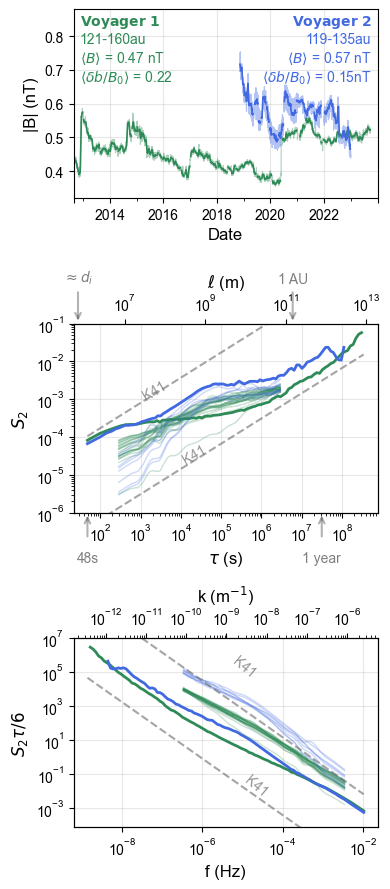

In [132]:
import matplotlib.pyplot as plt
import numpy as np


def create_voyager_analysis_plot(
    v1_res,
    v2_res,
    v1_sfs_corrected,
    v2_sfs_corrected,
    lags_v1_hr,
    sf_v1_hr,
    lags_v2_hr,
    sf_v2_hr,
    es_v1_f,
    es_v1_hr,
    es_v2_f,
    es_v2_hr,
):
    """
    Create a comprehensive three-panel plot for Voyager magnetic field analysis.

    Parameters:
    -----------
    v1_res, v2_res : pandas.DataFrame
        Voyager 1 and 2 magnetic field data with 'F1' column
    v1_sfs_corrected, v2_sfs_corrected : pandas.DataFrame
        Corrected structure function data
    lags_v1_hr, sf_v1_hr, lags_v2_hr, sf_v2_hr : array-like
        Structure function lags and values
    es_v1_f, es_v1_hr, es_v2_f, es_v2_hr : array-like
        Equivalent spectra frequencies and values
    """

    # Constants
    U = 25000  # m/s (solar wind speed)
    AU = 1.496e11  # meters (1 astronomical unit)
    DI = 700000  # Ion inertial length in km

    # Create figure with optimized layout
    fig, axes = plt.subplots(3, 1, figsize=(4, 9))

    # Color scheme
    colors = {
        "v1": "#2E8B57",  # Sea green
        "v2": "#4169E1",  # Royal blue
        "reference": "#696969",  # Dim gray
        "k41": "#708090",  # Slate gray
    }

    # =============================================================================
    # Panel 1: Magnetic Field Time Series
    # =============================================================================
    ax1 = axes[0]

    # Plot daily averages with transparency
    v1_res["F1"].plot(
        ax=ax1,
        label="Voyager 1 daily avg",
        color=colors["v1"],
        linewidth=0.8,
        alpha=0.4,
    )
    v2_res["F1"].plot(
        ax=ax1,
        label="Voyager 2 daily avg",
        color=colors["v2"],
        linewidth=0.8,
        alpha=0.4,
    )

    # Add 2-week moving averages
    v1_res["F1"].rolling(window=14, center=True).mean().plot(
        ax=ax1, label="V1 2-week moving avg", color=colors["v1"], linewidth=1.2
    )
    v2_res["F1"].rolling(window=14, center=True).mean().plot(
        ax=ax1, label="V2 2-week moving avg", color=colors["v2"], linewidth=1.2
    )

    # Formatting
    ax1.set_ylabel("|B| (nT)", fontsize=12)
    ax1.set_xlabel("Date", fontsize=12)
    ax1.set_ylim(0.32, 0.88)
    ax1.grid(True, alpha=0.3)

    # Add mission information
    _add_mission_info(ax1, colors)

    # =============================================================================
    # Panel 2: Structure Functions
    # =============================================================================
    ax2 = axes[1]

    # Main structure functions
    ax2.loglog(lags_v1_hr * 48, sf_v1_hr, color=colors["v1"], label="V1", linewidth=2)
    ax2.loglog(lags_v2_hr * 48, sf_v2_hr, color=colors["v2"], label="V2", linewidth=2)

    # Corrected structure functions
    _plot_corrected_sfs(ax2, v1_sfs_corrected, colors["v1"], scale_factor=3000)
    _plot_corrected_sfs(ax2, v2_sfs_corrected, colors["v2"], scale_factor=3000)

    # Kolmogorov reference lines
    _add_k41_references_sf(ax2, colors["reference"])

    # Formatting
    ax2.set_xlabel("$\\tau$ (s)", fontsize=12)
    ax2.set_ylabel("$S_2$", fontsize=12)
    ax2.set_ylim(1e-6, 1e-1)
    ax2.grid(True, alpha=0.3)
    #ax2.legend(fontsize=10)

    # Add secondary axis for spatial scales
    ax2_spatial = _add_spatial_axis(ax2, U)

    # Add time and length scale annotations
    _add_scale_annotations(ax2, ax2_spatial)

    # =============================================================================
    # Panel 3: Equivalent Spectra
    # =============================================================================
    ax3 = axes[2]

    # Main equivalent spectra
    ax3.loglog(es_v1_f, es_v1_hr, label="V1", color=colors["v1"], linewidth=2)
    ax3.loglog(es_v2_f, es_v2_hr, label="V2", color=colors["v2"], linewidth=2)

    # Corrected equivalent spectra
    _plot_corrected_es(ax3, v1_sfs_corrected, colors["v1"])
    _plot_corrected_es(ax3, v2_sfs_corrected, colors["v2"], scale_factor=10)

    # Kolmogorov reference lines
    _add_k41_references_es(ax3, es_v1_f, colors["reference"])

    # Formatting
    ax3.set_xlabel("f (Hz)", fontsize=12)
    ax3.set_ylabel("$S_2\\tau/6$", fontsize=12)
    ax3.set_ylim(7e-5, 1e7)
    ax3.grid(True, alpha=0.3)
    #ax3.legend(fontsize=10)

    # Add secondary axis for wavenumber
    _add_wavenumber_axis(ax3, U)

    # Final layout adjustments
    plt.tight_layout()
    return fig


def _add_mission_info(ax, colors):
    """Add mission information text boxes."""
    # Voyager 1 info
    ax.text(
        0.02,
        0.98,
        "$\\bf{Voyager\ 1}$\n121-160au\n$⟨B⟩$ = 0.47 nT\n$⟨\delta b/B_0⟩$ = 0.22",
        transform=ax.transAxes,
        fontsize=10,
        color=colors["v1"],
        verticalalignment="top",
        # bbox=dict(
        #     boxstyle="round,pad=0.3",
        #     facecolor="white",
        #     edgecolor=colors["v1"],
        #     alpha=0.8,
        # ),
    )

    # Voyager 2 info
    ax.text(
        0.98,
        0.98,
        "$\\bf{Voyager\ 2}$\n119-135au\n$⟨B⟩$ = 0.57 nT\n$⟨\delta b/B_0⟩$ = 0.15nT",
        transform=ax.transAxes,
        fontsize=10,
        color=colors["v2"],
        verticalalignment="top",
        horizontalalignment="right",
        # bbox=dict(
        #     boxstyle="round,pad=0.3",
        #     facecolor="white",
        #     edgecolor=colors["v2"],
        #     alpha=0.8,
        # ),
    )


def _plot_corrected_sfs(ax, sfs_corrected, color, scale_factor=1):
    """Plot corrected structure functions."""
    for idx in sfs_corrected["int_index"].unique():
        subset = sfs_corrected[sfs_corrected["int_index"] == idx]
        ax.loglog(
            subset["lag_s"],
            subset["sf_2"] / scale_factor,
            alpha=0.25,
            color=color,
            linewidth=1,
        )


def _plot_corrected_es(ax, sfs_corrected, color, scale_factor=1):
    """Plot corrected equivalent spectra."""
    for idx in sfs_corrected["int_index"].unique():
        subset = sfs_corrected[sfs_corrected["int_index"] == idx]
        ax.loglog(
            subset["inverse_lag_s"],
            subset["sf_corrected_es"] * scale_factor,
            alpha=0.25,
            color=color,
            linewidth=1,
        )


def _add_k41_references_sf(ax, color):
    """Add Kolmogorov 2/3 power law references to structure function plot."""
    tau_range = np.logspace(np.log10(48), np.log10(11 * 365 * 86400), 100)

    # Two reference lines with different amplitudes
    ax.loglog(
        tau_range,
        3.1e-8 * tau_range ** (2 / 3),
        color=color,
        linestyle="--",
        alpha=0.6,
        linewidth=1.5,
    )
    ax.loglog(
        tau_range,
        8e-6 * tau_range ** (2 / 3),
        color=color,
        linestyle="--",
        alpha=0.6,
        linewidth=1.5,
    )

    # Add K41 labels
    ax.text(1e3, 1e-3, "K41", rotation=30, alpha=0.7, fontsize=10, color=color)
    ax.text(1e4, 2e-5, "K41", rotation=30, alpha=0.7, fontsize=10, color=color)


def _add_k41_references_es(ax, freq_range, color):
    """Add Kolmogorov -5/3 power law references to equivalent spectra plot."""
    f_range = np.linspace(freq_range[-1], freq_range[0], 100)

    # Two reference lines with different amplitudes
    ax.loglog(
        f_range,
        3.1e-6 * f_range ** (-5 / 3),
        color=color,
        linestyle="--",
        alpha=0.6,
        linewidth=1.5,
    )
    ax.loglog(
        f_range,
        8e-11 * f_range ** (-5 / 3),
        color=color,
        linestyle="--",
        alpha=0.6,
        linewidth=1.5,
    )

    # Add K41 labels
    ax.text(1e-5, 5e-3, "K41", rotation=-40, alpha=0.7, fontsize=10, color=color)
    ax.text(5e-6, 5e4, "K41", rotation=-40, alpha=0.7, fontsize=10, color=color)


def _add_spatial_axis(ax, solar_wind_speed):
    """Add secondary x-axis for spatial scales."""
    ax_spatial = ax.twiny()
    lag_min, lag_max = ax.get_xlim()
    length_min, length_max = lag_min * solar_wind_speed, lag_max * solar_wind_speed
    ax_spatial.set_xlim(length_min, length_max)
    ax_spatial.set_xscale("log")
    ax_spatial.set_xlabel("$\ell$ (m)", fontsize=12)
    return ax_spatial


def _add_wavenumber_axis(ax, solar_wind_speed):
    """Add secondary x-axis for wavenumber."""
    ax_k = ax.twiny()
    freq_min, freq_max = ax.get_xlim()
    k_min, k_max = (
        2 * np.pi * freq_min / solar_wind_speed,
        2 * np.pi * freq_max / solar_wind_speed,
    )
    ax_k.set_xlim(k_min, k_max)
    ax_k.set_xscale("log")
    ax_k.set_xlabel("k (m$^{-1}$)", fontsize=12)
    return ax_k


def _add_scale_annotations(ax_time, ax_spatial):
    """Add time and length scale annotations."""
    AU = 1.496e11
    DI = 700000

    # Time scale annotations
    time_scales = [(48, "48s"), (365 * 86400, "1 year")]
    for time_val, label in time_scales:
        ax_time.annotate(
            "",
            xy=(time_val, 1e-6),
            xytext=(time_val, 2e-7),
            arrowprops=dict(arrowstyle="->", color="black", lw=1.5, alpha=0.3),
        )
        ax_time.text(
            time_val, 1e-7, label, ha="center", va="top", fontsize=10, alpha=0.5
        )

    # Length scale annotations
    length_scales = [(AU, "1 AU"), (DI, "$\\approx d_i$")]
    for length_val, label in length_scales:
        ax_spatial.annotate(
            "",
            xy=(length_val, 1),
            xytext=(length_val, 1.18),
            xycoords=("data", "axes fraction"),
            arrowprops=dict(arrowstyle="->", color="black", lw=1.5, alpha=0.3),
            annotation_clip=False,
        )
        ax_spatial.text(
            length_val,
            1.2,
            label,
            ha="center",
            va="bottom",
            transform=ax_spatial.get_xaxis_transform(),
            fontsize=10,
            alpha=0.5,
            clip_on=False,
        )


# Example usage:
fig = create_voyager_analysis_plot(v1_res, v2_res, v1_sfs_corrected, v2_sfs_corrected,
                                  lags_v1_hr, sf_v1_hr, lags_v2_hr, sf_v2_hr,
                                  es_v1_f, es_v1_hr, es_v2_f, es_v2_hr)
plt.savefig("voyager_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

In [26]:
Bx = v1_raw["BR"]
By = v1_raw["BT"]
Bz = v1_raw["BN"]

Bx_mean = Bx.mean()
By_mean = By.mean()
Bz_mean = Bz.mean()

# Calculate magnetic field magnitude B0
B0 = np.sqrt(Bx_mean**2 + By_mean**2 + Bz_mean**2)
print(f"B0: {B0:.3f} nT")
# Calculate rms magnetic field fluctuations, db
dbx = Bx - Bx_mean
dby = By - By_mean
dbz = Bz - Bz_mean
db = np.sqrt(np.mean(dbx**2 + dby**2 + dbz**2))

print(f"db: {db:.3f} nT")
# Calculate the ratio of fluctuations to mean field
ratio = db / B0
print(f"Ratio of fluctuations to mean field: {ratio:.3f}")

B0: 0.457 nT
db: 0.102 nT
Ratio of fluctuations to mean field: 0.224


In [27]:
Bx = v2_raw["BR"]
By = v2_raw["BT"]
Bz = v2_raw["BN"]

Bx_mean = Bx.mean()
By_mean = By.mean()
Bz_mean = Bz.mean()

# Calculate magnetic field magnitude B0
B0 = np.sqrt(Bx_mean**2 + By_mean**2 + Bz_mean**2)
print(f"B0: {B0:.3f} nT")
# Calculate rms magnetic field fluctuations, db
dbx = Bx - Bx_mean
dby = By - By_mean
dbz = Bz - Bz_mean
db = np.sqrt(np.mean(dbx**2 + dby**2 + dbz**2))

print(f"db: {db:.3f} nT")
# Calculate the ratio of fluctuations to mean field
ratio = db / B0
print(f"Ratio of fluctuations to mean field: {ratio:.3f}")

B0: 0.570 nT
db: 0.087 nT
Ratio of fluctuations to mean field: 0.153


In [28]:
v2_raw.mean()

F1    0.573884
BR    0.025768
BT   -0.496491
BN    0.278930
dtype: float32

NOTE: Thepthong does not account for amplitude bias, and assumes wavenumber bias $b$ to be one (see eqn 32, footnote 93 in Mark's paper)

- HR SFs eventually match the LR versions, later for V2, probably due to smaller sample size.
- V1 flattens out considerably at smaller scales.
- V2 flattens out to hump at around 12h-1 day.

Potentially relevant? 

- [Statistical inference of random field auto-correlation structure from multiple sets of incomplete and sparse measurements using Bayesian compressive sampling-based bootstrapping](https://www.sciencedirect.com/science/article/pii/S0888327019300652#s0065)
- [Interpolation uncertainty of atmospheric temperature profiles](https://amt.copernicus.org/articles/13/6445/2020/amt-13-6445-2020.html)